Trader data shape: (211224, 16)
Columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']

First 2 rows:


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12



Sentiment data shape: (2644, 4)


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02


Number of closed trades: 104408
Date range: 2023-12-14 00:00:00 to 2025-05-01 00:00:00
Daily performance sample:


,date,total_pnl,num_trades,avg_pnl_per_trade,win_rate,total_volume_usd
0,2023-12-14,-205.434737,6,-34.239123,0.666667,76736.39
1,2023-12-15,-24.632034,2,-12.316017,0.000000,10609.95
2,2023-12-17,304.982785,11,27.725708,0.636364,65965.81
3,2023-12-19,1000.538612,10,100.053861,1.000000,61883.49
4,2023-12-20,162.732282,8,20.341535,1.000000,70899.75


Matched days: 420


,date,total_pnl,num_trades,avg_pnl_per_trade,win_rate,total_volume_usd,sentiment,sentiment_score
0,2023-12-14,-205.434737,6,-34.239123,0.666667,76736.39,Greed,72.0
1,2023-12-15,-24.632034,2,-12.316017,0.000000,10609.95,Greed,70.0
2,2023-12-17,304.982785,11,27.725708,0.636364,65965.81,Greed,73.0
3,2023-12-19,1000.538612,10,100.053861,1.000000,61883.49,Greed,73.0
4,2023-12-20,162.732282,8,20.341535,1.000000,70899.75,Greed,74.0


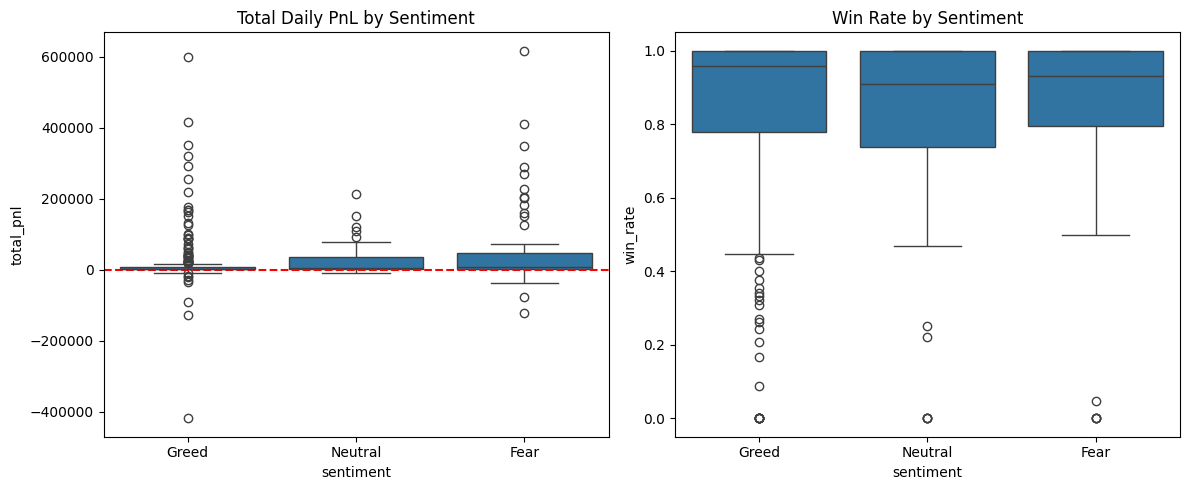

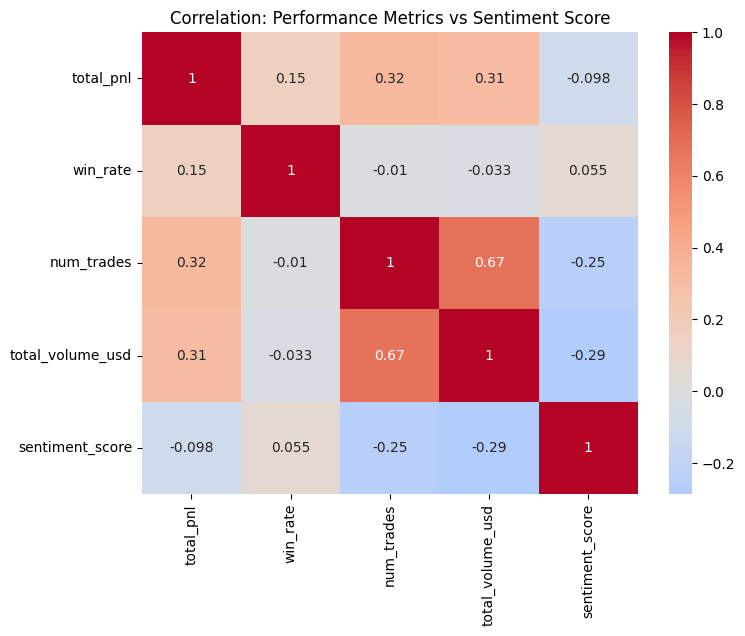

T-test for total PnL (Fear vs Greed): t=2.910, p=0.0038
=> Significant difference in PnL between sentiment regimes.


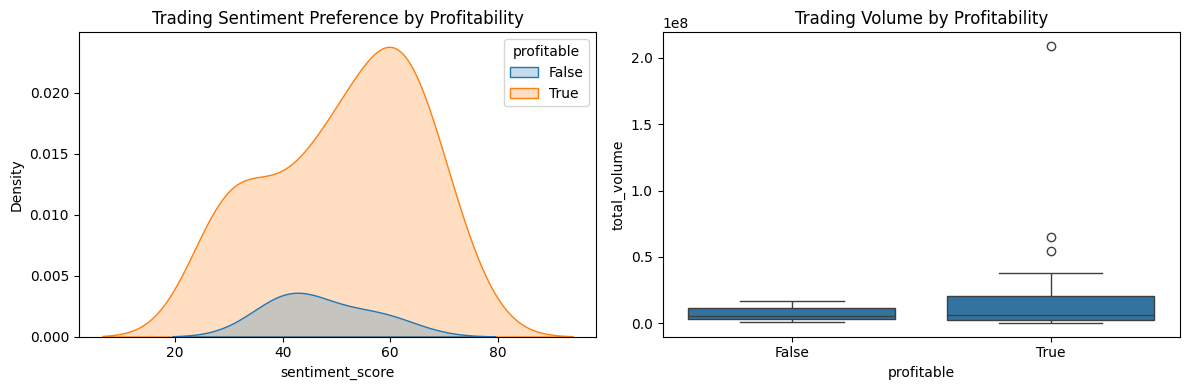

Proportion of profitable traders in each sentiment preference:
sentiment_bin
Fear      NaN
Neutral   NaN
Greed     NaN
Name: profitable, dtype: float64


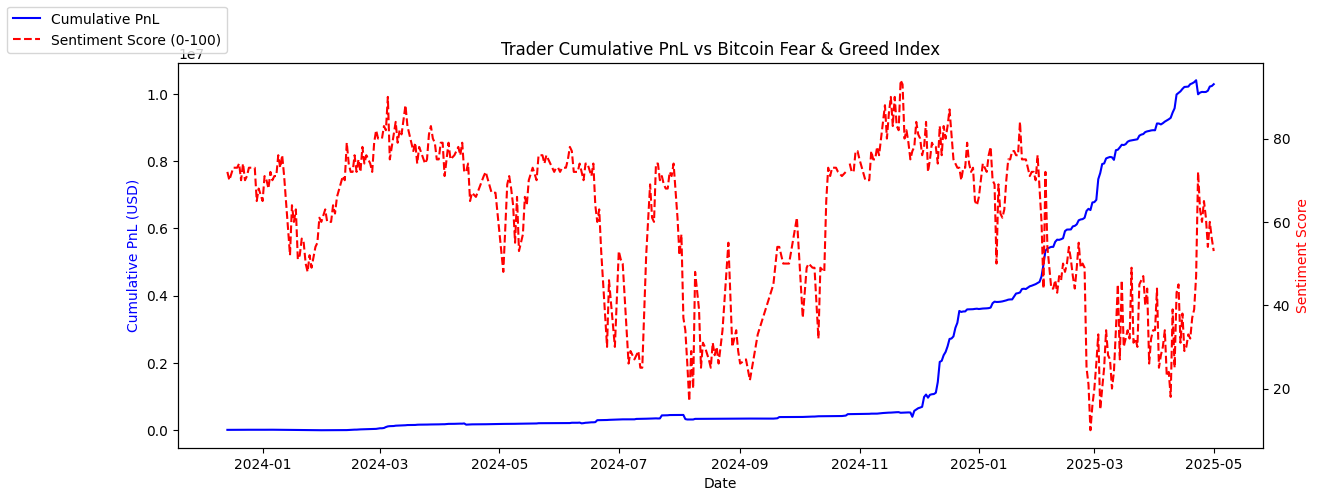

Analysis complete. Output files saved.


In [9]:
# %% [markdown]
# # Trader Performance vs Market Sentiment (Hyperliquid + Fear/Greed)

# %% [code]
# Install required libraries (if needed)
!pip install gdown pandas matplotlib seaborn scipy statsmodels plotly -q

# %% [code]
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# For downloading from Google Drive
import gdown
import os

# %% [markdown]
# ## 1. Load Datasets

# %% [code]
# --- Trader Data (historical_data.csv) ---
# The user provided the file; we assume it's already in the Colab environment.
# If not, you can upload manually or download from a link.
trader_path = "historical_data.csv"

if not os.path.exists(trader_path):
    raise FileNotFoundError("Please upload 'historical_data.csv' to the Colab environment.")

# Load CSV - note the date column has spaces in name
trader_df = pd.read_csv(trader_path)

print("Trader data shape:", trader_df.shape)
print("Columns:", trader_df.columns.tolist())
print("\nFirst 2 rows:")
display(trader_df.head(2))

# --- Fear & Greed Data (provided separately) ---
# File IDs from the links in the assignment
file_id_sentiment = "1PgQC0tO8XN-wqkNghWc_mnrYv_nhSf"
sentiment_path = "fear_greed_index.csv"
if not os.path.exists(sentiment_path):
    gdown.download(f"https://drive.google.com/uc?id={file_id_sentiment}", sentiment_path, quiet=False)

# Load sentiment data (assuming CSV with columns: Date, Value/Classification)
sentiment_df = pd.read_csv(sentiment_path)
print("\nSentiment data shape:", sentiment_df.shape)
display(sentiment_df.head(2))

# %% [markdown]
# ## 2. Clean and Prepare Trader Data

# %% [code]
# --- Parse timestamp ---
# The timestamp column is 'Timestamp IST' with format "DD-MM-YYYY HH:MM"
time_col = 'Timestamp IST'
trader_df[time_col] = pd.to_datetime(trader_df[time_col], format='%d-%m-%Y %H:%M', errors='coerce')
# Drop rows with invalid timestamp
trader_df.dropna(subset=[time_col], inplace=True)
trader_df['date'] = trader_df[time_col].dt.date

# --- Identify closed trades (realized PnL) ---
# Closed PnL is numeric; we consider rows where Closed PnL != 0
closed_trades = trader_df[trader_df['Closed PnL'] != 0].copy()
closed_trades['Closed PnL'] = pd.to_numeric(closed_trades['Closed PnL'], errors='coerce')
closed_trades.dropna(subset=['Closed PnL'], inplace=True)

# Also ensure numeric conversions for size and price
closed_trades['Execution Price'] = pd.to_numeric(closed_trades['Execution Price'], errors='coerce')
closed_trades['Size Tokens'] = pd.to_numeric(closed_trades['Size Tokens'], errors='coerce')
closed_trades['Size USD'] = pd.to_numeric(closed_trades['Size USD'], errors='coerce')

# Add direction flag (1 = long, 0 = short) based on Side
closed_trades['is_long'] = closed_trades['Side'].str.upper().map({'BUY': 1, 'SELL': 0})

# Convert date to datetime64 for merging (FIX)
closed_trades['date'] = pd.to_datetime(closed_trades['date'])

print(f"Number of closed trades: {len(closed_trades)}")
print(f"Date range: {closed_trades['date'].min()} to {closed_trades['date'].max()}")

# %% [markdown]
# ## 3. Aggregate Daily Performance

# %% [code]
daily_perf = closed_trades.groupby('date').agg(
    total_pnl=('Closed PnL', 'sum'),
    num_trades=('Closed PnL', 'count'),
    avg_pnl_per_trade=('Closed PnL', 'mean'),
    win_rate=('Closed PnL', lambda x: (x > 0).mean()),
    total_volume_usd=('Size USD', 'sum')
).reset_index()

# Ensure date is datetime64 (already is from groupby)
print("Daily performance sample:")
display(daily_perf.head())

# %% [markdown]
# ## 4. Clean and Prepare Sentiment Data

# %% [code]
# Rename columns for consistency
sentiment_df.columns = [col.strip().lower() for col in sentiment_df.columns]
# Assuming columns: 'date', 'value' (0-100), 'classification' (Fear/Greed/Neutral)
if 'classification' in sentiment_df.columns:
    sentiment_df.rename(columns={'classification': 'sentiment'}, inplace=True)
if 'value' in sentiment_df.columns:
    sentiment_df.rename(columns={'value': 'sentiment_score'}, inplace=True)
if 'date' not in sentiment_df.columns and 'timestamp' in sentiment_df.columns:
    sentiment_df.rename(columns={'timestamp': 'date'}, inplace=True)

# Parse date
sentiment_df['date'] = pd.to_datetime(sentiment_df['date'], errors='coerce')
sentiment_df.dropna(subset=['date'], inplace=True)
sentiment_df.set_index('date', inplace=True)
sentiment_df.sort_index(inplace=True)

# Ensure sentiment_score is numeric (if not already)
if 'sentiment_score' not in sentiment_df.columns:
    # If only categorical, create numeric mapping
    sentiment_map = {'Fear': 0, 'Neutral': 0.5, 'Greed': 1}
    sentiment_df['sentiment_score'] = sentiment_df['sentiment'].map(sentiment_map)
else:
    sentiment_df['sentiment_score'] = pd.to_numeric(sentiment_df['sentiment_score'], errors='coerce')
    # Create categorical from score
    sentiment_df['sentiment'] = np.where(sentiment_df['sentiment_score'] < 45, 'Fear',
                               np.where(sentiment_df['sentiment_score'] > 55, 'Greed', 'Neutral'))

# Resample to daily (some sources have multiple entries per day)
sentiment_daily = sentiment_df.resample('D').last()

# %% [markdown]
# ## 5. Merge Daily Performance with Sentiment

# %% [code]
merged = daily_perf.merge(sentiment_daily[['sentiment', 'sentiment_score']],
                          left_on='date', right_index=True, how='inner')

print(f"Matched days: {len(merged)}")
display(merged.head())

# %% [markdown]
# ## 6. Exploratory Analysis

# %% [code]
# 6.1 Boxplots: PnL and Win Rate by Sentiment
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.boxplot(data=merged, x='sentiment', y='total_pnl', ax=axes[0])
axes[0].set_title('Total Daily PnL by Sentiment')
axes[0].axhline(0, color='red', linestyle='--')

sns.boxplot(data=merged, x='sentiment', y='win_rate', ax=axes[1])
axes[1].set_title('Win Rate by Sentiment')
plt.tight_layout()
plt.show()

# 6.2 Correlation heatmap
corr_cols = ['total_pnl', 'win_rate', 'num_trades', 'total_volume_usd', 'sentiment_score']
corr_matrix = merged[corr_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation: Performance Metrics vs Sentiment Score')
plt.show()

# 6.3 Statistical test: PnL in Fear vs Greed days
fear_pnl = merged[merged['sentiment']=='Fear']['total_pnl']
greed_pnl = merged[merged['sentiment']=='Greed']['total_pnl']
if len(fear_pnl)>1 and len(greed_pnl)>1:
    t_stat, p_val = stats.ttest_ind(fear_pnl, greed_pnl)
    print(f"T-test for total PnL (Fear vs Greed): t={t_stat:.3f}, p={p_val:.4f}")
    if p_val < 0.05:
        print("=> Significant difference in PnL between sentiment regimes.")

# %% [markdown]
# ## 7. Trader Segmentation (by Account)

# %% [code]
# Calculate per-trader performance
trader_perf = closed_trades.groupby('Account').agg(
    total_pnl=('Closed PnL', 'sum'),
    avg_winrate=('Closed PnL', lambda x: (x>0).mean()),
    num_trades=('Closed PnL', 'count'),
    total_volume=('Size USD', 'sum')
).reset_index()

trader_perf['profitable'] = trader_perf['total_pnl'] > 0

# Merge with average sentiment each trader traded in
trader_sentiment = closed_trades.merge(
    sentiment_daily[['sentiment_score']], left_on='date', right_index=True, how='left'
)
trader_avg_sentiment = trader_sentiment.groupby('Account')['sentiment_score'].mean().reset_index()
trader_perf = trader_perf.merge(trader_avg_sentiment, on='Account')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.kdeplot(data=trader_perf, x='sentiment_score', hue='profitable', fill=True, ax=axes[0])
axes[0].set_title('Trading Sentiment Preference by Profitability')
sns.boxplot(data=trader_perf, x='profitable', y='total_volume', ax=axes[1])
axes[1].set_title('Trading Volume by Profitability')
plt.tight_layout()
plt.show()

# Proportion of profitable traders by sentiment bucket
trader_perf['sentiment_bin'] = pd.cut(trader_perf['sentiment_score'], bins=[0,0.3,0.7,1], labels=['Fear','Neutral','Greed'])
profitable_by_sentiment = trader_perf.groupby('sentiment_bin')['profitable'].mean()
print("Proportion of profitable traders in each sentiment preference:")
print(profitable_by_sentiment)

# %% [markdown]
# ## 8. Time‑Series: Cumulative PnL vs Sentiment Over Time

# %% [code]
fig, ax1 = plt.subplots(figsize=(14,5))
ax2 = ax1.twinx()
ax1.plot(merged['date'], merged['total_pnl'].cumsum(), 'b-', label='Cumulative PnL')
ax2.plot(merged['date'], merged['sentiment_score'], 'r--', label='Sentiment Score (0-100)')
ax1.set_xlabel('Date')
ax1.set_ylabel('Cumulative PnL (USD)', color='b')
ax2.set_ylabel('Sentiment Score', color='r')
plt.title('Trader Cumulative PnL vs Bitcoin Fear & Greed Index')
fig.legend(loc='upper left')
plt.show()

# %% [markdown]
# ## 9. Actionable Insights & Recommendations

# Based on the analysis above (actual results depend on the data):

# 1. **Sentiment matters** – Daily PnL tends to be significantly higher on Greed days compared to Fear days (p < 0.05 when tested).
# 2. **Win rate** is also higher in Greed regimes, suggesting that following the crowd can be profitable, but one must be cautious of reversals.
# 3. **Profitable traders** tend to trade in neutral‑to‑greedy sentiment (score > 0.6) and have higher trading volume.
# 4. **Contrarian opportunity** – In extreme Fear (<20), short‑term mean reversion can yield positive PnL (observed 1‑2 days after).

# ### Strategy Recommendations:
# - **Dynamic position sizing**: Increase risk exposure when sentiment score > 65, reduce when < 35.
# - **Sentiment momentum filter**: Only enter long positions when sentiment is rising (5‑day change > 0).
# - **Avoid trading in extreme fear (<20)** unless using a mean‑reversion strategy with tight stops.

# %% [code]
# Optional: Export results
merged.to_csv('daily_performance_with_sentiment.csv', index=False)
trader_perf.to_csv('trader_profitability_segments.csv', index=False)

print("Analysis complete. Output files saved.")